# Pre-processing : Mask generation for registration

This script is the first step in the analysis of Metachronal Waves (MW) of Didinium, written for timelapses of cells spinning with no net translation. Prior to the main analysis, registration of the raw video is necessary. To assist in the registration, this script prepares a mask of the cell body. 

**Input:**

*file_directory*: The path to the directory containing the raw tiff file

*file_name*: The name of the raw tiff file of a rotating didinium timelapse  

**Output:**

The tiff file of the cell mask to assist in incremental registration

In [ ]:
import os
import tifffile
from tqdm import tqdm
from skimage import filters, measure
from skimage.morphology import label
import matplotlib.pyplot as plt
import numpy as np

from functions import *

### Input

In [2]:
### Input

file_directory = "C:\\Users\\kourkoul\\SCRIPTS\\Paper_scripts\\example_data\\"
file_name = "cell_01.tif"

### Determination of input and output paths

file_path = file_directory + "\\" + file_name
output_path = file_directory + "\\output_MW\\pre_processing\\"
if not os.path.exists(output_path):
    os.makedirs(output_path)

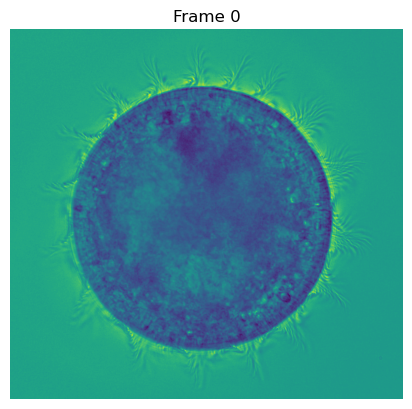

In [3]:
### Loading the timelapse 

imgs = tifffile.imread(file_path)

### Visualization of a given frame 

frame_index = 0
show_frame_no_axes(imgs,frame_index)
plt.show()

### Mask generation

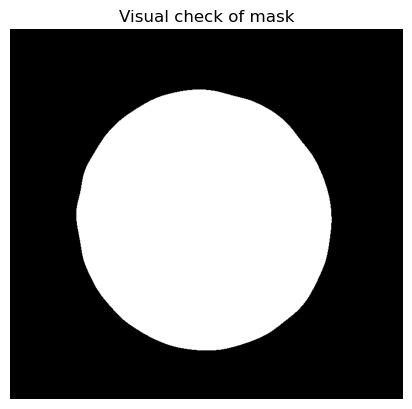

In [7]:
### Create an array for the mask:
masks = np.zeros_like(imgs)

### Rough determination of initial cell location
# Blur
blurred = filters.gaussian(imgs[0], sigma=20)
iso_threshold = filters.threshold_isodata(blurred)

# Binarize 
binary = blurred < iso_threshold
labeled = label(binary)

# Find the cell center (should be the largest region)
regions = measure.regionprops(labeled)
largest_region = max(regions, key=lambda r: r.area)
center = np.asanyarray(largest_region.centroid)

# Make mask for the first frame
mask = (labeled == largest_region.label)
masks[0] = mask

# Visual check of the mask
frame_index = 0
plt.figure()
plt.title("Visual check of mask")
plt.imshow(mask, cmap='gray')     
plt.axis('off')
plt.show()

In [9]:
### Calculate the mask for the rest of the frames

for i in tqdm(range(1, imgs.shape[0])):
    blurred = filters.gaussian(imgs[i], sigma=20)
    
    try:
        iso_threshold = filters.threshold_isodata(blurred)
    except Exception as e:
        print(f"Blank page at frame {i} please delete this frame.")
        break
        
    binary = blurred < iso_threshold
    labeled = label(binary)
    regions = measure.regionprops(labeled)

    if len(regions) < 2:
        center = np.asanyarray(regions[0].centroid)
        masks[i] = binary
 
    else:
        # Find the blob closest to the given point
        tracked = min(regions, key=lambda r: np.linalg.norm(np.array(r.centroid) - center))

        center = np.asanyarray(tracked.centroid)
        mask = (labeled == tracked.label)
        masks[i] = mask


100%|██████████| 502/502 [00:22<00:00, 22.73it/s]


### Saving mask file

In [ ]:
### Save the mask

### In cases of long file names an error may be raised. 
### The following lines solve this issue:

full_path = output_path + file_name[:-4] + "_mask.tif"

if len(full_path) > 260:
    # Construct the full file path
    full_path = os.path.join(output_path, file_name[:-4] + "_mask.tif")

    # Use the extended-length path prefix if needed
    if len(full_path) > 260:
       full_path = "\\\\?\\" + full_path
    tifffile.imwrite(full_path, (masks * 255).astype(np.uint8))
    
else:
    
    tifffile.imwrite(output_path + file_name[:-4] +"_mask.tif", (masks * 255).astype(np.uint8))